In [1]:
import torch
import torch.nn.functional as F

import gymnasium as gym

In [2]:
torch.cuda.is_available()

True

In [3]:
env = gym.make("CartPole-v1", render_mode="rgb_array")

In [4]:
action_space_size = env.action_space.n
action_space_size

2

In [5]:
observation_space_size = env.observation_space.shape[0]
observation_space_size

4

In [6]:
env.observation_space.sample()

array([ 3.6957326 ,  0.58405846, -0.23383343,  0.5375613 ], dtype=float32)

In [7]:
env.reset()
env.step(env.action_space.sample())

(array([ 0.01591162,  0.19700728, -0.01266683, -0.3147755 ], dtype=float32),
 1.0,
 False,
 False,
 {})

In [8]:
import imageio

In [9]:
env.reset()
truncated = False
terminated = False
frames = []

while not (truncated or terminated):
    frames.append(env.render())
    state, reward, terminated, truncated, info = env.step(env.action_space.sample())

imageio.mimsave(
    "episode.mp4",
    frames,
    fps=30
)

/home/shashank/micromamba/envs/rl/lib/python3.9/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [11]:
import torch.nn as nn
from torch.distributions import Categorical
import torch.optim as optim

In [44]:
class Policy(nn.Module):
    def __init__(self, action_space_size, hidden_size, observation_space_size):
        super().__init__()
        self.fc = nn.ModuleList()
        self.fc.append(nn.Linear(observation_space_size, hidden_size[0]))
        for h1, h2 in zip(hidden_size, hidden_size[1:]):
            self.fc.append(nn.Linear(h1, h2))
        self.fc.append(nn.Linear(hidden_size[-1], action_space_size))

    def forward(self, inputs):
        out = inputs
        for fc in self.fc[:-1]:
            out = fc(out)
            out = F.relu(out)
        return F.softmax(self.fc[-1](out), dim=-1)
    
    def act(self, state):
        state = torch.from_numpy(state).float().to(device)
        probs = self.forward(state)
        dist = Categorical(probs)
        action = dist.sample()
        return action.cpu().item(), dist.log_prob(action).cpu()

In [45]:
p = Policy(
    action_space_size=action_space_size,
    hidden_size=[8, 8],
    observation_space_size=observation_space_size
)

p = p.to(device)

In [46]:
sum(i.numel() for i in p.parameters())

130

In [47]:
p(torch.from_numpy(env.observation_space.sample()).float().to(device))

tensor([0.4564, 0.5436], device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [48]:
p.act(env.observation_space.sample())

(1, tensor(-0.5319, grad_fn=<ToCopyBackward0>))

In [49]:
from collections import deque
import numpy as np

In [ ]:
def reinforce(
    policy: nn.Module,
    optimizer: optim.Optimizer,
    n_training_episodes: int,
    max_t: int,
    gamma: float,
    print_every: int
):
    scores_deque = deque(maxlen=100)
    scores = []

    for i_episode in range(1, n_training_episodes+1):
        saved_log_probs = []
        rewards = []

        state, _ = env.reset()
        for t in range(max_t):
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, terminated, truncated, _ = env.step(action)
            rewards.append(reward)
            if terminated or truncated:
                break

        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        returns = deque(maxlen=max_t)
        n_steps = len(rewards)

        for t in range(n_steps)[::-1]:
            prev = returns[0] if len(returns)>0 else 0
            returns.appendleft((prev * gamma) + rewards[t])

        eps = np.finfo(np.float32).eps.item()
        
        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + eps)

        policy_loss = []
        for log_prob, disc_return in zip(saved_log_probs, returns):
            policy_loss.append(-log_prob * disc_return)

        policy_loss = torch.stack(policy_loss).sum()

        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if i_episode%print_every == 0:
            print(f"Episode {i_episode}: \tAverage Score: {np.mean(scores_deque)}\tPolicy Loss: {policy_loss}\tDiscounted Reward: {returns[0]}")

    return scores

In [151]:
cartpole_hyperparameters = {
    "hidden_size": [32, 32],
    "n_training_episodes": 1000,
    "n_eval_episodes": 10,
    "max_t": 1000,
    "gamma": 0.99,
    "lr": 1e-3,
    "env_id": "CartPole-v1",
    "state_space": observation_space_size,
    "action_space": int(action_space_size)
}

In [92]:
cartpole_policy = Policy(
    action_space_size=cartpole_hyperparameters["action_space"],
    hidden_size=cartpole_hyperparameters["hidden_size"],
    observation_space_size=cartpole_hyperparameters["state_space"]
)

cartpole_policy = cartpole_policy.to(device)

In [93]:
sum([p.numel() for p in cartpole_policy.parameters()])

1282

In [94]:
cartpole_optimizer = optim.Adam(
    cartpole_policy.parameters(),
    lr=cartpole_hyperparameters["lr"]
)

In [95]:
scores = reinforce(
    policy=cartpole_policy,
    optimizer=cartpole_optimizer,
    n_training_episodes=cartpole_hyperparameters["n_training_episodes"],
    max_t=cartpole_hyperparameters['max_t'],
    gamma=cartpole_hyperparameters['gamma'],
    print_every=50
)

Episode 50: 	Average Score: 22.96	Policy Loss: -0.4318234324455261	Discounted Reward: 1.499929666519165
Episode 100: 	Average Score: 25.07	Policy Loss: -0.678594708442688	Discounted Reward: 1.5699636936187744
Episode 150: 	Average Score: 28.96	Policy Loss: 0.45006418228149414	Discounted Reward: 1.5487138032913208
Episode 200: 	Average Score: 39.47	Policy Loss: -0.7067438364028931	Discounted Reward: 1.5576894283294678
Episode 250: 	Average Score: 69.49	Policy Loss: -1.124947190284729	Discounted Reward: 1.523765206336975
Episode 300: 	Average Score: 118.2	Policy Loss: -4.482336044311523	Discounted Reward: 1.1755999326705933
Episode 350: 	Average Score: 206.11	Policy Loss: -3.0661492347717285	Discounted Reward: 1.185495376586914
Episode 400: 	Average Score: 302.46	Policy Loss: -1.2573184967041016	Discounted Reward: 0.7766653299331665
Episode 450: 	Average Score: 285.86	Policy Loss: -15.495769500732422	Discounted Reward: 0.7885596752166748
Episode 500: 	Average Score: 320.55	Policy Loss: -

In [96]:
import matplotlib.pyplot as plt

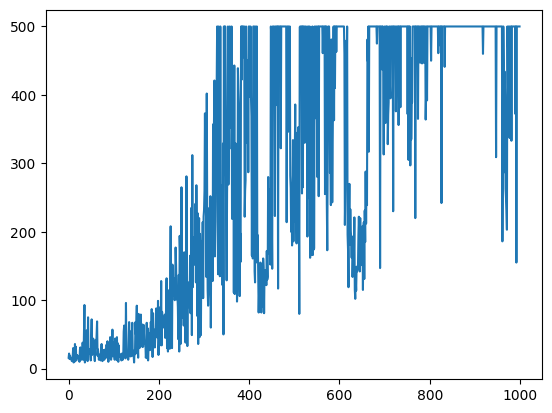

In [97]:
plt.plot(scores)

In [158]:
def evaluate_agent(n_eval_episodes, policy, max_steps, env_id):
    scores = []

    for _ in range(n_eval_episodes):
        total_reward = 0.0

        env = gym.make(env_id)
        obs, info = env.reset()

        for _ in range(max_steps):
            action, log_prob = policy.act(obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            if terminated or truncated:
                break

        scores.append(total_reward)

    scores = torch.tensor(scores)
    return torch.mean(scores).item(), torch.std(scores).item()

In [159]:
mean, std = evaluate_agent(10, cartpole_policy, 1000, "CartPole-v1")
print(f"Mean of rewards: {mean}, std of rewards: {std}")

Mean of rewards: 478.20001220703125, std of rewards: 68.93765258789062


In [135]:
def record_video(env_id, policy, max_steps, gamma, video_path):
    env = gym.make(env_id, render_mode="rgb_array")
    state, _ = env.reset()

    frames = []
    n_steps = 0
    rewards = []
    frames.append(env.render())

    for _ in range(max_steps):
        action, log_prob = policy.act(state)
        state, reward, terminated, truncated, _ = env.step(action)
        n_steps+=1
        rewards.append(reward)       
        frames.append(env.render())
        if terminated or truncated:
            break

    for i in range(1, len(rewards))[::-1]:
        rewards[i-1] += gamma*rewards[i]

    print(f"Number of steps in episode: {n_steps}, discounted reward: {rewards[0]}")

    imageio.mimsave(
        video_path,
        frames,
        fps=30
    )

In [136]:
record_video("CartPole-v1", cartpole_policy, 1000, 0.99, "episode.mp4")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Number of steps in episode: 500, discounted reward: 99.34295169575849


In [133]:
torch.save(cartpole_policy, "cartpole-model.pt")

In [129]:
from PIL import Image
from io import BytesIO
import torchviz

obs = env.observation_space.sample()
act, log_prob = cartpole_policy.act(obs)

b = BytesIO(torchviz.make_dot(log_prob).pipe(format="png"))
img = Image.open(b)

img.save("image.png", "png")

In [134]:
from huggingface_hub import HfApi, snapshot_download
from huggingface_hub.repocard import metadata_eval_result, metadata_save

In [143]:
import json
import tempfile
from pathlib import Path
import datetime

In [ ]:
def push_to_hub(
    repo_id
):
    env_id = "CartPole-v1"

    _, repo_name = repo_id.split("/")
    api = HfApi()

    # Step 1: Create the repo
    repo_url = api.create_repo(
        repo_id=repo_id,
        exist_ok=True,
    )

    with tempfile.TemporaryDirectory() as tmpdirname:
        local_directory = Path(tmpdirname)

        # Step 2: Save the model
        torch.save(cartpole_policy, f"{local_directory}/model.pt")

        # Step 3: Save the hyperparameters to JSON
        with open(local_directory / "hyperparameters.json", "w") as outfile:
            json.dump(cartpole_hyperparameters, outfile)

        # Step 4: Evaluate the model and build JSON
        mean_reward, std_reward = evaluate_agent(
                            cartpole_hyperparameters["n_eval_episodes"],
                            cartpole_policy,
                            cartpole_hyperparameters["max_t"],
                            "CartPole-v1"
                        )
        # Get datetime
        eval_datetime = datetime.datetime.now()
        eval_form_datetime = eval_datetime.isoformat()

        evaluate_data = {
            "env_id": cartpole_hyperparameters["env_id"],
            "mean_reward": mean_reward,
            "n_evaluation_episodes": cartpole_hyperparameters["n_eval_episodes"],
            "eval_datetime": eval_form_datetime,
        }

        # Write a JSON file
        with open(local_directory / "results.json", "w") as outfile:
            json.dump(evaluate_data, outfile)

        # Step 5: Create the model card
        env_name = cartpole_hyperparameters["env_id"]

        metadata = {}
        metadata["tags"] = [
            env_name,
            "reinforce",
            "reinforcement-learning",
            "custom-implementation",
            "deep-rl-class"
        ]

        # Add metrics
        eval = metadata_eval_result(
            model_pretty_name=repo_name,
            task_pretty_name="reinforcement-learning",
            task_id="reinforcement-learning",
            metrics_pretty_name="mean_reward",
            metrics_id="mean_reward",
            metrics_value=f"{mean_reward:.2f} +/- {std_reward:.2f}",
            dataset_pretty_name=env_name,
            dataset_id=env_name,
        )

        # Merges both dictionaries
        metadata = {**metadata, **eval}

        model_card = f"""
        # **Reinforce** Agent playing **{env_id}**
        This is a trained model of a **Reinforce** agent playing **{env_id}** .
        To learn to use this model and train yours check Unit 4 of the Deep Reinforcement Learning Course: https://huggingface.co/deep-rl-course/unit4/introduction
        """

        readme_path = local_directory / "README.md"
        readme = ""
        if readme_path.exists():
            with readme_path.open("r", encoding="utf8") as f:
                readme = f.read()
        else:
            readme = model_card

        with readme_path.open("w", encoding="utf-8") as f:
            f.write(readme)

        # Save our metrics to Readme metadata
        metadata_save(readme_path, metadata)

        # Step 6: Record a video
        video_path =  local_directory / "replay.mp4"
        record_video(env_id, cartpole_policy, 1000, 0.99, video_path)

        # Step 7. Push everything to the Hub
        api.upload_folder(
            repo_id=repo_id,
            folder_path=local_directory,
            path_in_repo=".",
        )

    print(f"Your model is pushed to the Hub. You can view your model here: {repo_url}")

In [155]:
from huggingface_hub import notebook_login

In [141]:
notebook_login()

In [163]:
push_to_hub("Shashankk10/reinforce-cartpole-v1")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Number of steps in episode: 500, discounted reward: 99.34295169575849


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  /tmp/tmpw3zaf_o7/model.pt             : 100%|##########| 8.82kB / 8.82kB            

Your model is pushed to the Hub. You can view your model here: https://huggingface.co/Shashankk10/reinforce-cartpole-v1
